In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import re
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ===================== USER INPUT =====================
qe_nscf_file = "gr.nscf.out"   # NSCF output file name
alat_bohr     = 4.6412          # QE alat (Bohr)
Ef            = -4.2071         # Fermi level from QE (eV)
max_radius    = 0.4             # q-radius around K for cone plot (Å^-1)

# ======================================================
# 1) READ QE FILE, EXTRACT k + ALL BAND ENERGIES
# ======================================================
with open(qe_nscf_file, "r", errors="ignore") as f:
    lines = f.readlines()

num = r"[-+]?\d*\.?\d+(?:[EeDd][-+]?\d+)?"
k_header = re.compile(
    rf"^\s*k\s*=\s*({num})\s*({num})\s*({num})\s*\([^)]*PWs\)\s*bands\s*\(ev\)\s*:",
    re.IGNORECASE
)
num_pat = re.compile(num)

k_list = []
bands_list = []

i = 0
while i < len(lines):
    m = k_header.match(lines[i])
    if not m:
        i += 1
        continue

    kx, ky, kz = map(float, m.groups())

    j = i + 1
    energies = []
    while j < len(lines) and ("occupation numbers" not in lines[j].lower()) \
            and (not k_header.match(lines[j])):
        energies += num_pat.findall(lines[j])
        j += 1

    e = list(map(float, energies))
    if len(e) > 0:
        k_list.append([kx, ky])
        bands_list.append(e)

    i = j

k = np.array(k_list, float)          # kx, ky in QE units 2π/alat
Ebands = np.array(bands_list, float) # (Nk, Nbands)
Nk, Nb = Ebands.shape
print("Found Nk =", Nk, "k-points; Nb =", Nb, "bands")

# ======================================================
# 2) CONVERT k TO Å^-1
# ======================================================
alat_A = alat_bohr * 0.529177
factor = (2.0 * np.pi / alat_bohr) / 0.529177
kx_A = k[:, 0] * factor
ky_A = k[:, 1] * factor

# ======================================================
# 3) BUILD GRAPHENE 1st BZ HEXAGON AND FOLD
# ======================================================
a = alat_A
b1 = (2*np.pi/a) * np.array([1.0, -1.0/np.sqrt(3.0)])
b2 = (2*np.pi/a) * np.array([0.0,  2.0/np.sqrt(3.0)])

V6 = np.array([
    (2*b1 + b2)/3,
    (b1 + 2*b2)/3,
    (b1 - b2)/3,
    -(2*b1 + b2)/3,
    -(b1 + 2*b2)/3,
    -(b1 - b2)/3,
])

angles = np.arctan2(V6[:, 1], V6[:, 0])
V6 = V6[np.argsort(angles)]
V = np.vstack([V6, V6[0]])

def point_in_poly(x, y, poly):
    inside = False
    x0, y0 = poly[0]
    for ii in range(1, len(poly) + 1):
        x1, y1 = poly[ii % len(poly)]
        if ((y0 > y) != (y1 > y)):
            xinters = (x1 - x0) * (y - y0) / (y1 - y0 + 1e-30) + x0
            if x < xinters:
                inside = not inside
        x0, y0 = x1, y1
    return inside

def fold_to_1BZ(kx_in, ky_in, b1, b2, hex_vertices, search=2):
    K = np.column_stack([kx_in, ky_in])
    Kf = np.zeros_like(K)

    shifts = []
    for m in range(-search, search + 1):
        for n in range(-search, search + 1):
            shifts.append(m*b1 + n*b2)
    shifts = np.array(shifts)

    for idx, kpt in enumerate(K):
        kcands = kpt - shifts
        mask = np.array([point_in_poly(p[0], p[1], hex_vertices) for p in kcands])
        if np.any(mask):
            ins = kcands[mask]
            j = np.argmin(np.sum(ins**2, axis=1))
            Kf[idx] = ins[j]
        else:
            j = np.argmin(np.sum(kcands**2, axis=1))
            Kf[idx] = kcands[j]
    return Kf[:, 0], Kf[:, 1]

kx_fold, ky_fold = fold_to_1BZ(kx_A, ky_A, b1, b2, V6, search=2)

# ======================================================
# 4) DEDUPLICATE k AND AVERAGE BANDS
# ======================================================
tol = 1e-6
kx_r = np.round(kx_fold / tol) * tol
ky_r = np.round(ky_fold / tol) * tol
keys = np.column_stack([kx_r, ky_r])

uniqK, inv = np.unique(keys, axis=0, return_inverse=True)
Nk_u = len(uniqK)
Ebands_u = np.zeros((Nk_u, Nb))
counts = np.zeros(Nk_u)

for i in range(Nk):
    g = inv[i]
    Ebands_u[g] += Ebands[i]
    counts[g] += 1

Ebands_u /= counts[:, None]
kx_u = uniqK[:, 0]
ky_u = uniqK[:, 1]

print("After folding/dedup:", Nk, "→", Nk_u, "unique k-points")

# ======================================================
# 5) VALENCE / CONDUCTION AT EACH k
# ======================================================
Eval = np.empty(Nk_u)
Econd = np.empty(Nk_u)

for i in range(Nk_u):
    e = Ebands_u[i]
    below = e[e <= Ef]
    above = e[e >= Ef]
    if len(below) == 0 or len(above) == 0:
        Eval[i] = np.nan
        Econd[i] = np.nan
    else:
        Eval[i]  = below.max()
        Econd[i] = above.min()

gap = Econd - Eval
print("Gap stats (eV): min =", np.nanmin(gap), "max =", np.nanmax(gap))

# save for later use if you want
np.savetxt(
    "graphene_k_val_cond_unique.txt",
    np.column_stack([kx_u, ky_u, Eval, Econd]),
    header="kx_A^-1 ky_A^-1 Eval_eV Econd_eV"
)

Found Nk = 3969 k-points; Nb = 20 bands
After folding/dedup: 3969 → 3969 unique k-points
Gap stats (eV): min = 0.0 max = 11.3399


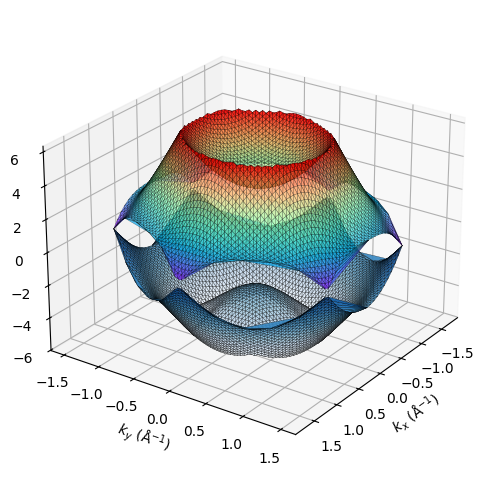

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# load k, Eval, Econd (file created by the big script)
data = np.loadtxt("graphene_k_val_cond_unique.txt")
kx = data[:,0]
ky = data[:,1]
Eval = data[:,2]
Econd = data[:,3]

Ef = -4.2071
Eval -= Ef
Econd -= Ef

# triangulation over whole BZ
tri = mtri.Triangulation(kx, ky)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(tri, Eval, cmap="Blues", alpha=0.9, linewidth=0.2, edgecolor="k")
ax.plot_trisurf(tri, Econd, cmap="rainbow", alpha=0.7, linewidth=0.2, edgecolor="k")

ax.set_xlabel(r"$k_x$ ($\mathrm{\AA^{-1}}$)")
ax.set_ylabel(r"$k_y$ ($\mathrm{\AA^{-1}}$)")
ax.set_zlabel(r"$E$ (eV)")

# choose a more “top‑down” viewing angle like the reference
ax.view_init(elev=25, azim=35)

#plt.tight_layout()
plt.savefig("graphene_surface_band_structure.jpg", dpi=300, bbox_inches="tight")
plt.show()
